# Projeto AV2 - Previsão de Preços de Imóveis

## 1. Objetivo da Análise

O problema consiste em prever o preço de venda de imóveis residenciais a partir de características como área, qualidade geral, bairro, garagem, porão, ano de construção e outros atributos.

A variável alvo é `SalePrice`, que representa o preço de venda do imóvel em dólares. A análise será guiada por quatro perguntas principais:

1. Como a variável `SalePrice` está distribuída?
2. Quais variáveis parecem ter maior relação com o preço?
3. Quais problemas de dados existem, principalmente valores ausentes e outliers?
4. Qual estratégia de limpeza será usada antes da modelagem?

## 2. Importação das Bibliotecas e Carregamento dos Dados

Nesta seção, carregamos as bibliotecas usadas na análise e lemos os arquivos `treino.csv` e `teste_publico.csv`.

A base de treino contém a variável alvo `SalePrice`. A base de teste público não contém `SalePrice`, pois simula dados novos que futuramente serão usados pelo pipeline de predição.

In [24]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda valor: f"{valor:,.2f}")

sns.set_theme(style="whitegrid", palette="Set2")

CAMINHO_TREINO = Path("treino.csv")
CAMINHO_TESTE = Path("teste_publico.csv")
CAMINHO_DICIONARIO = Path("data_description.txt")

treino = pd.read_csv(CAMINHO_TREINO)
teste = pd.read_csv(CAMINHO_TESTE)

treino.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,255,20,RL,70.00,8400,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1957,1957,Gable,CompShg,MetalSd,MetalSd,NaN,0.00,TA,Gd,CBlock,TA,TA,No,Rec,922,Unf,0,392,1314,GasA,TA,Y,SBrkr,1314,0,0,1314,1,0,1,0,3,1,TA,5,Typ,0,NaN,Attchd,"1,957.00",RFn,1,294,TA,TA,Y,250,0,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal,145000
1,1067,60,RL,59.00,7837,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,7,1993,1994,Gable,CompShg,VinylSd,VinylSd,NaN,0.00,Gd,TA,PConc,Gd,TA,No,Unf,0,Unf,0,799,799,GasA,Gd,Y,SBrkr,799,772,0,1571,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,"1,993.00",RFn,2,380,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,5,2009,WD,Normal,178000
2,639,30,RL,67.00,8777,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Feedr,Norm,1Fam,1Story,5,7,1910,1950,Gable,CompShg,MetalSd,Wd Sdng,NaN,0.00,TA,TA,CBlock,Fa,TA,No,Unf,0,Unf,0,796,796,GasA,Gd,Y,FuseA,796,0,0,796,0,0,1,0,2,1,TA,4,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,P,328,0,164,0,0,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal,85000
3,800,50,RL,60.00,7200,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,SWISU,Feedr,Norm,1Fam,1.5Fin,5,7,1937,1950,Gable,CompShg,Wd Sdng,Wd Sdng,BrkFace,252.00,TA,TA,BrkTil,Gd,TA,No,ALQ,569,Unf,0,162,731,GasA,Ex,Y,SBrkr,981,787,0,1768,1,0,1,1,3,1,Gd,7,Typ,2,TA,Detchd,"1,939.00",Unf,1,240,TA,TA,Y,0,0,264,0,0,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal,175000
4,381,50,RL,50.00,5000,Pave,Pave,Reg,Lvl,AllPub,Inside,Gtl,SWISU,Norm,Norm,1Fam,1.5Fin,5,6,1924,1950,Gable,CompShg,BrkFace,Wd Sdng,NaN,0.00,TA,TA,BrkTil,TA,TA,No,LwQ,218,Unf,0,808,1026,GasA,TA,Y,SBrkr,1026,665,0,1691,0,0,2,0,3,1,Gd,6,Typ,1,Gd,Detchd,"1,924.00",Unf,1,308,TA,TA,Y,0,0,242,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,127000


## 3. Visão Geral das Bases

Antes de analisar padrões, é importante conferir o tamanho das bases, a existência da variável alvo e os tipos de dados disponíveis. Essa etapa ajuda a entender se o problema envolve variáveis numéricas, categóricas ou ambas.

In [25]:
resumo_bases = pd.DataFrame({
    "Base": ["Treino", "Teste público"],
    "Linhas": [treino.shape[0], teste.shape[0]],
    "Colunas": [treino.shape[1], teste.shape[1]],
    "Possui SalePrice?": ["SalePrice" in treino.columns, "SalePrice" in teste.columns],
})

resumo_tipos = (
    treino.drop(columns="SalePrice")
    .dtypes
    .value_counts()
    .rename_axis("Tipo de dado")
    .reset_index(name="Quantidade de variaveis")
)

display(resumo_bases)
display(resumo_tipos)

,Base,Linhas,Colunas,Possui SalePrice?
0,Treino,1168,81,True
1,Teste público,1459,80,False


,Tipo de dado,Quantidade de variaveis
0,object,43
1,int64,34
2,float64,3


### Interpretação

A base de treino possui **1.168 imóveis** e inclui a variável alvo `SalePrice`. A base de teste público possui **1.459 imóveis** e não possui a variável alvo, como esperado.

A base contém variáveis numéricas e categóricas. Isso significa que a etapa de limpeza e pré-processamento precisará lidar com imputação de valores ausentes, tratamento de categorias e codificação de variáveis textuais antes da modelagem.

## 4. Análise da Variável Alvo `SalePrice`

A variável `SalePrice` é o preço que queremos prever. Entender sua distribuição é essencial, pois a competição usa a métrica **RMSLE**, que penaliza erros proporcionais. Por isso, distribuições muito assimétricas podem prejudicar modelos treinados diretamente no preço original.

In [26]:
preco = treino["SalePrice"]

resumo_preco = preco.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).to_frame("SalePrice")
resumo_preco.loc["assimetria"] = preco.skew()
resumo_preco.loc["assimetria_log1p"] = np.log1p(preco).skew()

resumo_preco

,SalePrice
count,"1,168.00"
mean,"181,441.54"
std,"77,263.58"
min,"34,900.00"
1%,"69,161.39"
5%,"89,675.00"
25%,"130,000.00"
50%,"165,000.00"
75%,"214,925.00"
95%,"327,300.00"


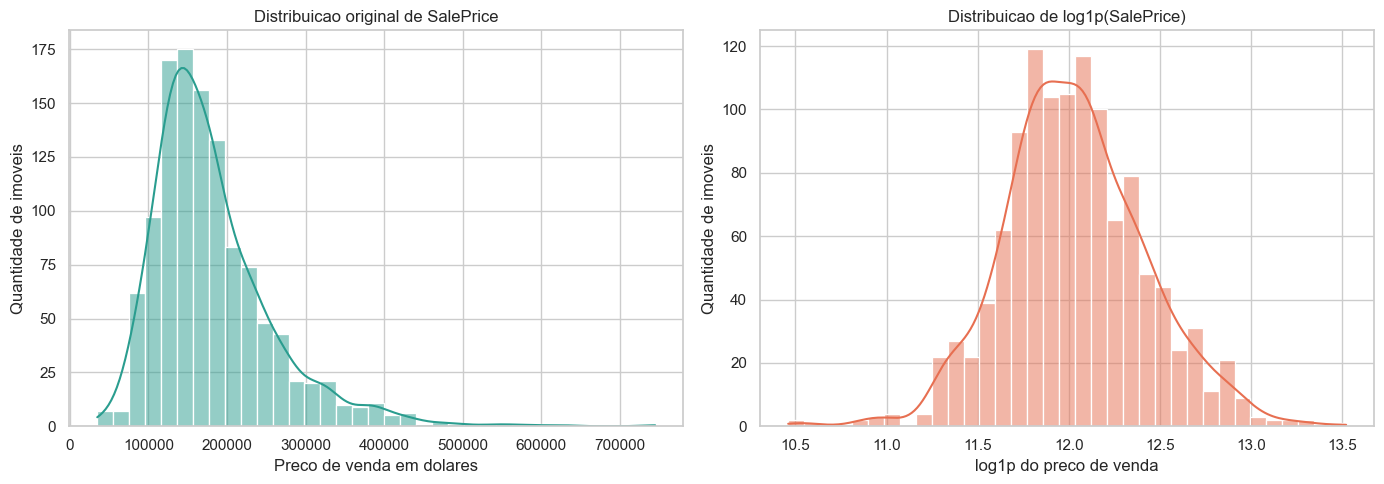

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(treino["SalePrice"], bins=35, kde=True, ax=axes[0], color="#2a9d8f")
axes[0].set_title("Distribuicao original de SalePrice")
axes[0].set_xlabel("Preco de venda em dolares")
axes[0].set_ylabel("Quantidade de imoveis")

sns.histplot(np.log1p(treino["SalePrice"]), bins=35, kde=True, ax=axes[1], color="#e76f51")
axes[1].set_title("Distribuicao de log1p(SalePrice)")
axes[1].set_xlabel("log1p do preco de venda")
axes[1].set_ylabel("Quantidade de imoveis")

plt.tight_layout()
plt.show()

### Interpretação

A distribuição original de `SalePrice` é assimétrica à direita: a maioria dos imóveis está em uma faixa intermediária de preço, enquanto poucos imóveis muito caros puxam a média para cima.

A transformação `log1p(SalePrice)` reduz bastante essa assimetria. Isso será importante na etapa de modelagem, porque a métrica RMSLE avalia erros em escala logarítmica. Portanto, uma estratégia futura recomendada é treinar o modelo com o alvo transformado em log e converter as previsões de volta para dólares com `expm1`.

## 5. Correlações Numéricas com o Preço

Nesta seção analisamos quais variáveis numéricas têm maior associação linear com `SalePrice`. Correlação não prova causalidade, mas ajuda a identificar atributos com forte sinal preditivo.

In [28]:
correlacoes = (
    treino.corr(numeric_only=True)["SalePrice"]
    .drop("SalePrice")
    .sort_values(ascending=False)
)

top_correlacoes = correlacoes.head(15).to_frame("Correlacao com SalePrice")
correlacoes_negativas = correlacoes.tail(10).to_frame("Correlacao com SalePrice")

display(top_correlacoes)
display(correlacoes_negativas)

,Correlacao com SalePrice
OverallQual,0.79
GrLivArea,0.70
GarageCars,0.64
GarageArea,0.62
TotalBsmtSF,0.60
1stFlrSF,0.59
FullBath,0.55
TotRmsAbvGrd,0.52
YearBuilt,0.52
YearRemodAdd,0.51


,Correlacao com SalePrice
BsmtFinSF2,-0.01
YrSold,-0.01
LowQualFinSF,-0.01
Id,-0.02
MiscVal,-0.02
BsmtHalfBath,-0.05
OverallCond,-0.07
MSSubClass,-0.09
KitchenAbvGr,-0.14
EnclosedPorch,-0.15


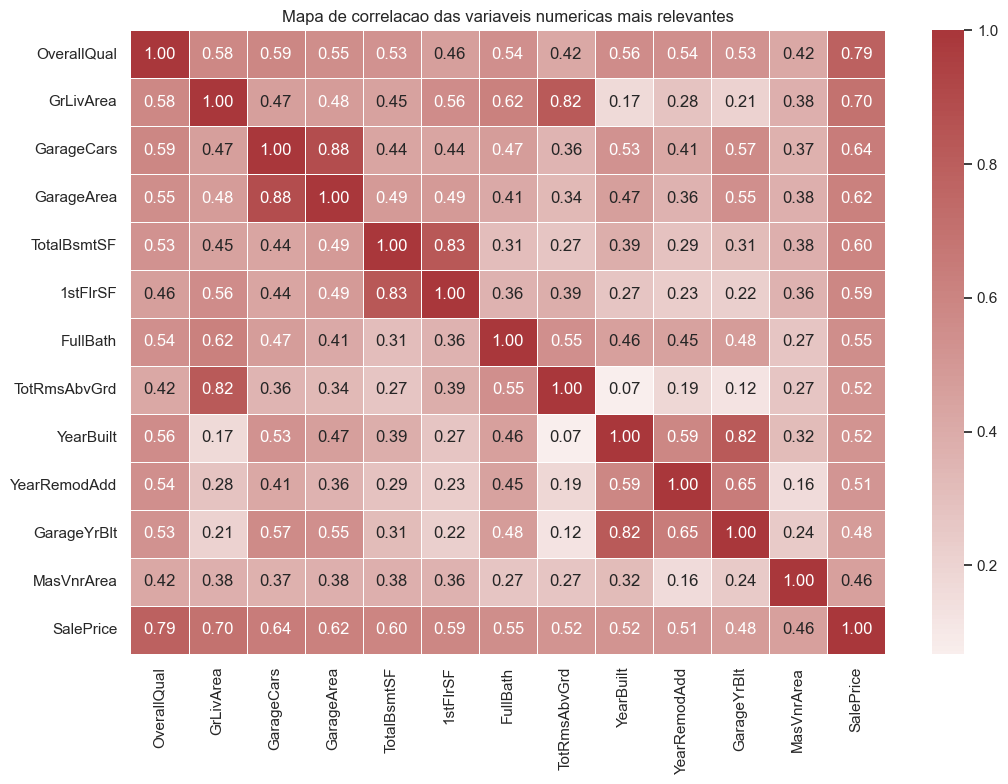

In [29]:
variaveis_mapa = correlacoes.abs().sort_values(ascending=False).head(12).index.tolist() + ["SalePrice"]

plt.figure(figsize=(11, 8))
sns.heatmap(
    treino[variaveis_mapa].corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidths=0.5,
)
plt.title("Mapa de correlacao das variaveis numericas mais relevantes")
plt.tight_layout()
plt.show()

### Interpretação

As variáveis com maior correlação positiva com o preço são coerentes com o problema:

- `OverallQual`: qualidade geral do imóvel.
- `GrLivArea`: área habitável acima do solo.
- `GarageCars` e `GarageArea`: capacidade e tamanho da garagem.
- `TotalBsmtSF` e `1stFlrSF`: áreas construídas relevantes.
- `YearBuilt` e `YearRemodAdd`: ano de construção e reforma.

Essas variáveis devem ser preservadas e tratadas com cuidado, pois carregam informação importante para a previsão do preço.

## 6. Relações Visuais com `SalePrice`

Agora observamos graficamente algumas relações importantes. O objetivo é validar se os padrões encontrados nas correlações fazem sentido visualmente.

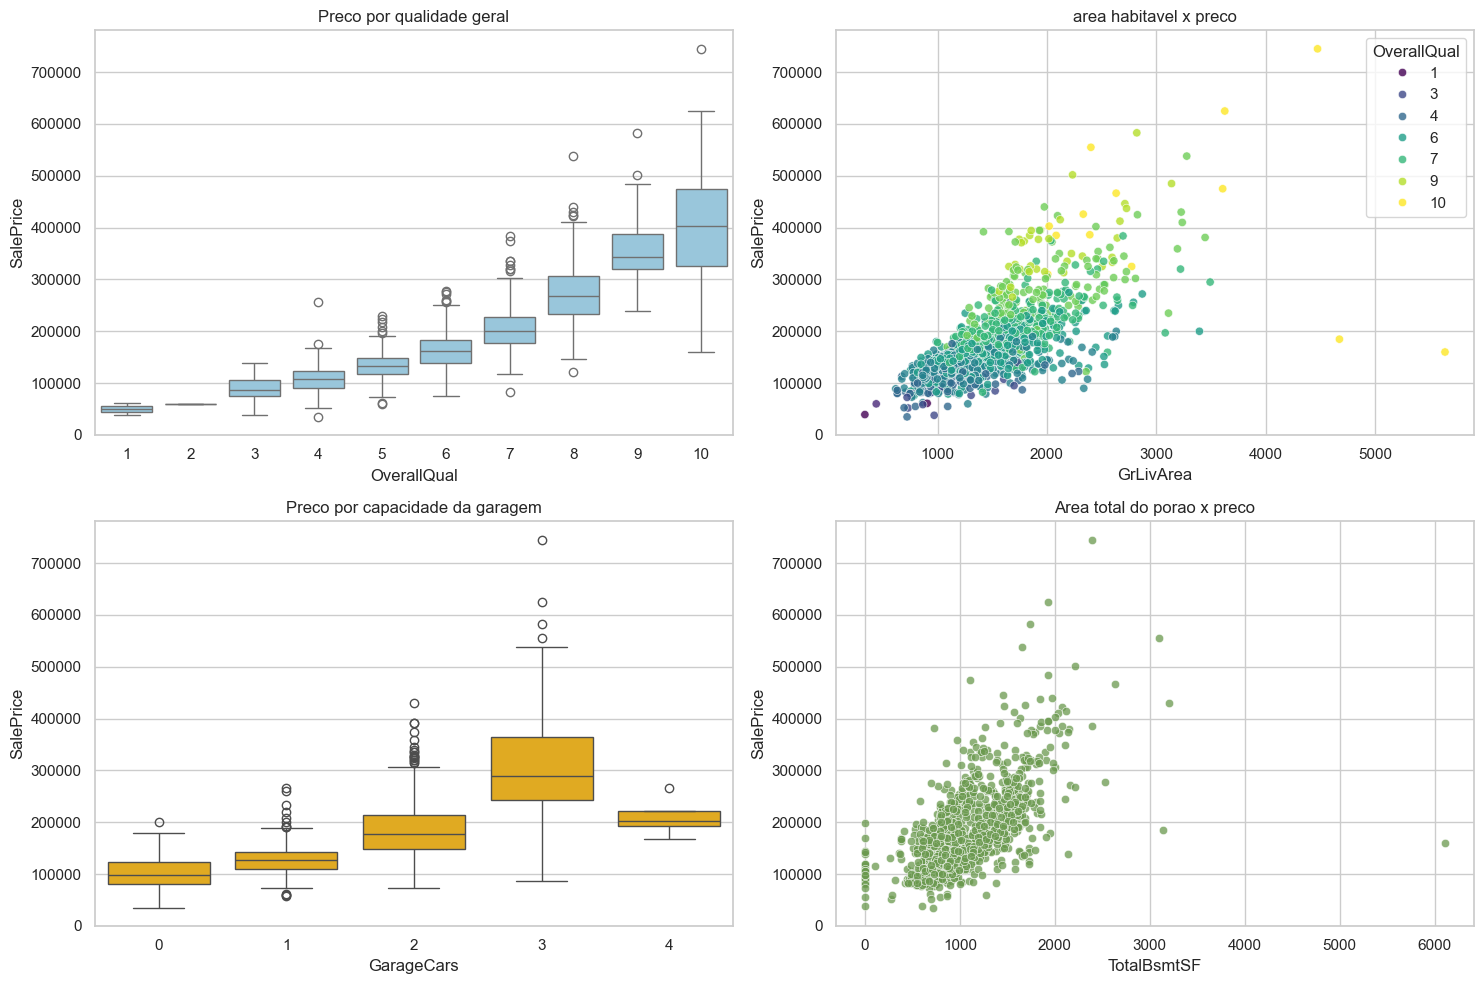

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.boxplot(data=treino, x="OverallQual", y="SalePrice", ax=axes[0, 0], color="#8ecae6")
axes[0, 0].set_title("Preco por qualidade geral")
axes[0, 0].set_xlabel("OverallQual")
axes[0, 0].set_ylabel("SalePrice")

sns.scatterplot(
    data=treino,
    x="GrLivArea",
    y="SalePrice",
    hue="OverallQual",
    palette="viridis",
    ax=axes[0, 1],
    alpha=0.8,
)
axes[0, 1].set_title("area habitavel x preco")
axes[0, 1].set_xlabel("GrLivArea")
axes[0, 1].set_ylabel("SalePrice")

sns.boxplot(data=treino, x="GarageCars", y="SalePrice", ax=axes[1, 0], color="#ffb703")
axes[1, 0].set_title("Preco por capacidade da garagem")
axes[1, 0].set_xlabel("GarageCars")
axes[1, 0].set_ylabel("SalePrice")

sns.scatterplot(data=treino, x="TotalBsmtSF", y="SalePrice", ax=axes[1, 1], color="#6a994e", alpha=0.75)
axes[1, 1].set_title("Area total do porao x preco")
axes[1, 1].set_xlabel("TotalBsmtSF")
axes[1, 1].set_ylabel("SalePrice")

plt.tight_layout()
plt.show()

### Interpretação

Os gráficos reforçam três conclusões principais:

1. Imóveis com maior `OverallQual` tendem a ter preços mais altos.
2. Existe relação positiva entre área habitável (`GrLivArea`) e preço.
3. Garagem e porão também contribuem para diferenciar imóveis de menor e maior valor.

Também é possível observar alguns pontos extremos, especialmente em `GrLivArea`, que serão avaliados na seção de outliers.

## 7. Análise de Variável Categórica: `Neighborhood`

O bairro costuma influenciar fortemente o preço de imóveis. Por isso, analisamos a mediana e a distribuição de `SalePrice` por `Neighborhood`.

In [31]:
preco_por_bairro = (
    treino.groupby("Neighborhood")["SalePrice"]
    .agg(quantidade="count", mediana="median", media="mean")
    .sort_values("mediana", ascending=False)
)

preco_por_bairro

,quantidade,mediana,media
Neighborhood,,,
NridgHt,61,"314,813.00","312,157.10"
NoRidge,33,"290,000.00","323,185.09"
StoneBr,20,"282,000.00","302,605.70"
Veenker,9,"245,500.00","251,944.44"
Somerst,69,"226,700.00","226,403.80"
Timber,28,"226,250.00","236,141.54"
ClearCr,19,"211,000.00","221,842.11"
Crawfor,44,"208,550.00","211,587.20"
CollgCr,115,"200,500.00","201,112.01"


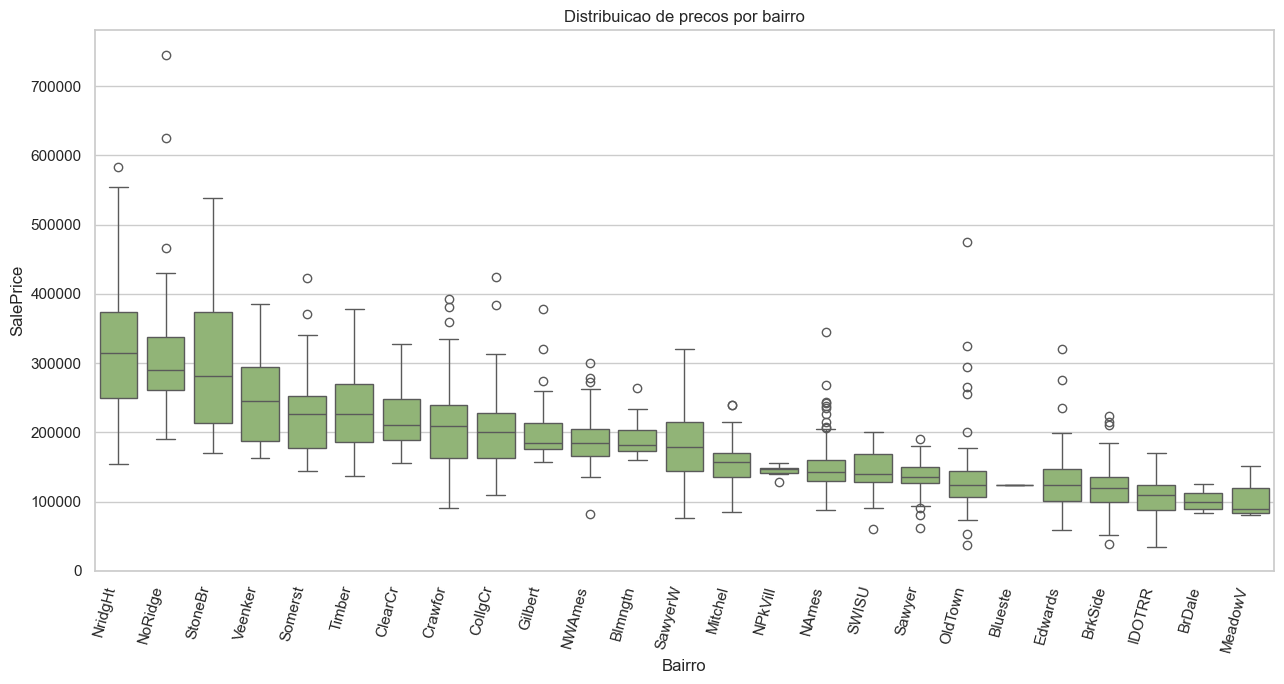

In [32]:
plt.figure(figsize=(13, 7))
ordem_bairros = preco_por_bairro.index
sns.boxplot(data=treino, x="Neighborhood", y="SalePrice", order=ordem_bairros, color="#90be6d")
plt.xticks(rotation=75, ha="right")
plt.title("Distribuicao de precos por bairro")
plt.xlabel("Bairro")
plt.ylabel("SalePrice")
plt.tight_layout()
plt.show()

### Interpretação

A variável `Neighborhood` apresenta diferenças claras de preço entre bairros. Alguns bairros possuem medianas muito superiores a outros, indicando que localização é uma informação relevante.

Como `Neighborhood` é categórica, ela deve ser transformada antes da modelagem. A estratégia recomendada é usar `OneHotEncoder(handle_unknown="ignore")`, pois a base de teste pode conter categorias que não apareceram no treino.

## 8. Diagnóstico de Valores Ausentes

Partindo que nem todo valor ausente representa erro. No dicionário de dados, várias colunas usam `NA` para indicar ausência de uma característica, como casa sem piscina, sem garagem, sem porão ou sem cerca.

Por isso, a análise de nulos precisa separar:

- **Nulos semânticos:** significam ausência de uma característica.
- **Nulos reais:** indicam falta de informação e precisam ser imputados.

In [33]:
def tabela_nulos(df, nome_base):
    nulos = df.isna().sum()
    return pd.DataFrame({
        f"nulos_{nome_base}": nulos,
        f"pct_{nome_base}": 100 * nulos / len(df),
    })

nulos_treino = tabela_nulos(treino, "treino")
nulos_teste = tabela_nulos(teste, "teste")

nulos = nulos_treino.join(nulos_teste, how="outer").fillna(0)
nulos = nulos[(nulos["nulos_treino"] > 0) | (nulos["nulos_teste"] > 0)]
nulos = nulos.sort_values("pct_treino", ascending=False)

nulos

,nulos_treino,pct_treino,nulos_teste,pct_teste
PoolQC,1162,99.49,"1,456.00",99.79
MiscFeature,1122,96.06,"1,408.00",96.50
Alley,1094,93.66,"1,352.00",92.67
Fence,935,80.05,"1,169.00",80.12
MasVnrType,683,58.48,894.00,61.27
FireplaceQu,547,46.83,730.00,50.03
LotFrontage,217,18.58,227.00,15.56
GarageFinish,64,5.48,78.00,5.35
GarageCond,64,5.48,78.00,5.35
GarageYrBlt,64,5.48,78.00,5.35


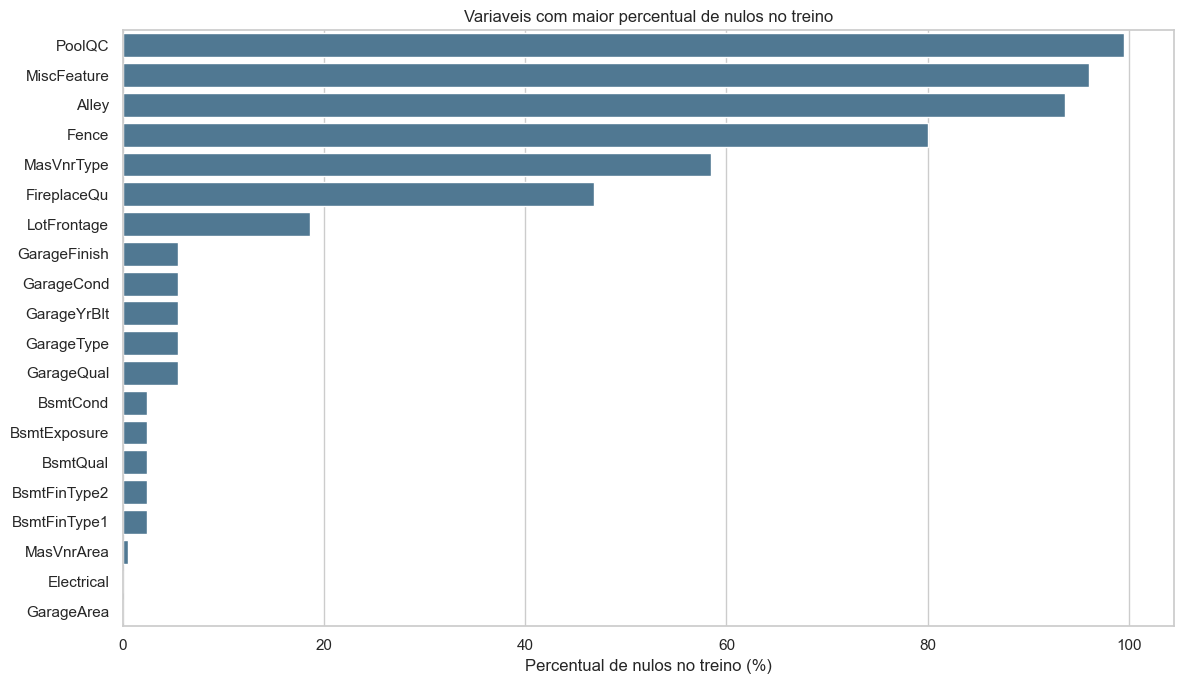

In [34]:
plt.figure(figsize=(12, 7))
nulos_plot = nulos.head(20).reset_index(names="Variavel")
sns.barplot(data=nulos_plot, y="Variavel", x="pct_treino", color="#457b9d")
plt.title("Variaveis com maior percentual de nulos no treino")
plt.xlabel("Percentual de nulos no treino (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Interpretação

As variáveis com mais nulos são `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `MasVnrType`, `FireplaceQu` e `LotFrontage`.

Pelo dicionário de dados, muitos desses nulos têm significado próprio. Por exemplo:

- `PoolQC`: nulo indica ausência de piscina.
- `Alley`: nulo indica ausência de acesso por beco.
- `Fence`: nulo indica ausência de cerca.
- `FireplaceQu`: nulo indica ausência de lareira.
- Variáveis de garagem nulas indicam ausência de garagem.
- Variáveis de porão nulas indicam ausência de porão.

Logo, não é adequado excluir automaticamente essas colunas. A melhor estratégia é transformar esses nulos em informação explícita.

## 9. Classificação dos Nulos e Estratégia de Tratamento

A tabela abaixo organiza os principais tipos de valores ausentes encontrados e a estratégia de limpeza proposta para cada grupo.

In [35]:
nulos_semanticos_categoricos = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu", "MasVnrType",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
]

nulos_semanticos_numericos = [
    "GarageYrBlt", "GarageCars", "GarageArea",
    "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath",
    "MasVnrArea",
]

nulos_reais_imputar = [
    "LotFrontage", "Electrical", "MSZoning", "Utilities", "Functional", "Exterior1st",
    "Exterior2nd", "KitchenQual", "SaleType",
]

plano_nulos = pd.DataFrame({
    "Grupo": [
        "Nulos semanticos categoricos",
        "Nulos semanticos numericos",
        "Nulos reais ou falhas de registro",
    ],
    "Tratamento proposto": [
        "Preencher com categoria explicita, como 'Nenhum'.",
        "Preencher com 0 quando ausencia da estrutura significar area ou quantidade zero.",
        "Imputar com mediana/moda calculada no treino; em LotFrontage, usar mediana por bairro.",
    ],
    "Exemplos de variaveis": [
        ", ".join([col for col in nulos_semanticos_categoricos if col in treino.columns]),
        ", ".join([col for col in nulos_semanticos_numericos if col in treino.columns or col in teste.columns]),
        ", ".join([col for col in nulos_reais_imputar if col in treino.columns or col in teste.columns]),
    ],
})

plano_nulos

,Grupo,Tratamento proposto,Exemplos de variaveis
0,Nulos semanticos categoricos,"Preencher com categoria explicita, como 'Nenhum'.","PoolQC, MiscFeature, Alley, Fence, FireplaceQu..."
1,Nulos semanticos numericos,Preencher com 0 quando ausencia da estrutura s...,"GarageYrBlt, GarageCars, GarageArea, BsmtFinSF..."
2,Nulos reais ou falhas de registro,Imputar com mediana/moda calculada no treino; ...,"LotFrontage, Electrical, MSZoning, Utilities, ..."


### Interpretação

A estratégia de limpeza preserva informação de negócio. Em vez de tratar todos os nulos como erro, o tratamento respeita o significado de cada variável.

Esse cuidado é importante porque uma casa sem piscina, sem garagem ou sem porão não está com dado faltante; ela possui uma característica real que influencia seu preço.

## 10. Outliers

Outliers são valores muito extremos que podem distorcer modelos, principalmente modelos lineares. Nesta base, a variável `GrLivArea` merece atenção, pois representa a área habitável acima do solo e tem forte relação com o preço.

In [36]:
outliers_area = treino.loc[
    treino["GrLivArea"] > 4000,
    ["Id", "Neighborhood", "OverallQual", "GrLivArea", "TotalBsmtSF", "GarageCars", "SalePrice"],
].sort_values("GrLivArea", ascending=False)

outliers_area

,Id,Neighborhood,OverallQual,GrLivArea,TotalBsmtSF,GarageCars,SalePrice
495,1299,Edwards,10,5642,6110,2,160000
365,524,Edwards,10,4676,3138,3,184750
173,1183,NoRidge,10,4476,2396,3,745000


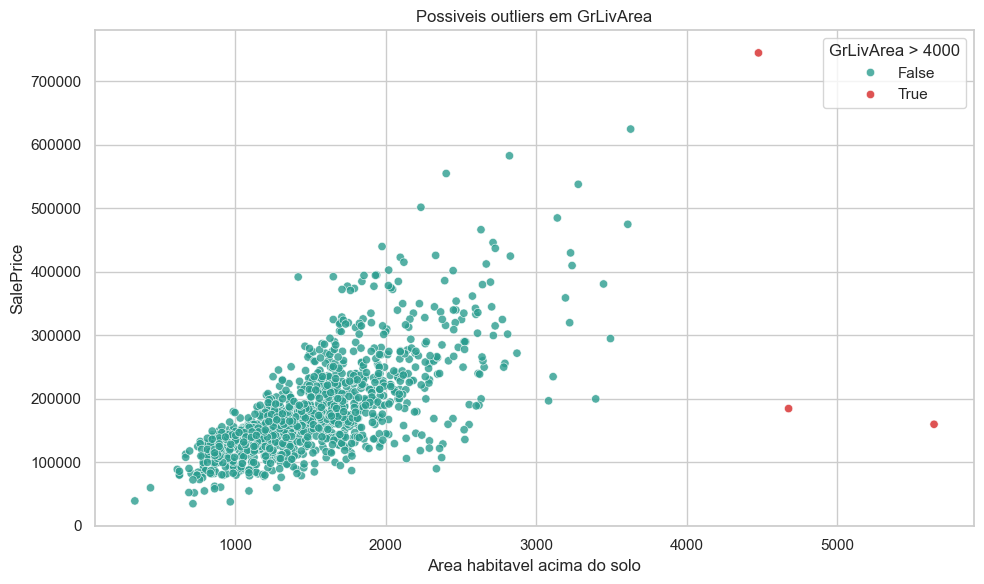

In [37]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=treino,
    x="GrLivArea",
    y="SalePrice",
    hue=treino["GrLivArea"] > 4000,
    palette={False: "#2a9d8f", True: "#d62828"},
    alpha=0.8,
)
plt.title("Possiveis outliers em GrLivArea")
plt.xlabel("Area habitavel acima do solo")
plt.ylabel("SalePrice")
plt.legend(title="GrLivArea > 4000")
plt.tight_layout()
plt.show()

### Interpretação

Existem imóveis com `GrLivArea` acima de 4.000 sqft. Dois deles possuem preço relativamente baixo apesar da área e da qualidade geral altas, o que pode indicar pontos atípicos.

A estratégia recomendada é avaliar esses casos com cuidado e, se necessário, remover outliers extremos apenas da base de treino. A base de teste não deve ser filtrada, pois no cenário real o modelo precisa prever qualquer imóvel recebido.

## 11. Compatibilidade entre Treino e Teste

Antes de definir a limpeza, também é necessário verificar se treino e teste possuem as mesmas variáveis explicativas e se existem categorias no teste que não aparecem no treino.

In [38]:
colunas_treino_sem_alvo = set(treino.columns) - {"SalePrice"}
colunas_teste = set(teste.columns)

compatibilidade = pd.DataFrame({
    "Item": [
        "Colunas explicativas no treino",
        "Colunas no teste",
        "Colunas faltantes no teste",
        "Colunas extras no teste",
    ],
    "Resultado": [
        len(colunas_treino_sem_alvo),
        len(colunas_teste),
        sorted(colunas_treino_sem_alvo - colunas_teste),
        sorted(colunas_teste - colunas_treino_sem_alvo),
    ],
})

compatibilidade

,Item,Resultado
0,Colunas explicativas no treino,80
1,Colunas no teste,80
2,Colunas faltantes no teste,[]
3,Colunas extras no teste,[]


In [39]:
categoricas = treino.drop(columns="SalePrice").select_dtypes(include="object").columns
categorias_novas = []

for coluna in categoricas:
    if coluna in teste.columns:
        novas = sorted(set(teste[coluna].dropna().unique()) - set(treino[coluna].dropna().unique()))
        if novas:
            categorias_novas.append({
                "Variavel": coluna,
                "Categorias no teste nao vistas no treino": novas,
            })

pd.DataFrame(categorias_novas)

""


### Interpretação

A base de teste público possui as mesmas colunas explicativas do treino. Porém, algumas variáveis categóricas podem apresentar categorias novas no teste.

Por isso, no pipeline futuro, o tratamento de variáveis categóricas deve usar uma configuração robusta, como `OneHotEncoder(handle_unknown="ignore")`, evitando erro quando aparecer uma categoria não vista durante o treino.

## 12. Demonstração da Limpeza Inicial

A função abaixo demonstra a estratégia de limpeza definida na análise inicial. Ela não substitui o pipeline final, mas mostra como os principais problemas serão tratados.

In [40]:
def limpeza_inicial_para_eda(df: pd.DataFrame) -> pd.DataFrame:
    dados = df.copy()

    colunas_categoricas_semanticas = [col for col in nulos_semanticos_categoricos if col in dados.columns]
    colunas_numericas_semanticas = [col for col in nulos_semanticos_numericos if col in dados.columns]

    dados[colunas_categoricas_semanticas] = dados[colunas_categoricas_semanticas].fillna("Nenhum")
    dados[colunas_numericas_semanticas] = dados[colunas_numericas_semanticas].fillna(0)

    if "LotFrontage" in dados.columns and "Neighborhood" in dados.columns:
        mediana_por_bairro = dados.groupby("Neighborhood")["LotFrontage"].transform("median")
        dados["LotFrontage"] = dados["LotFrontage"].fillna(mediana_por_bairro)
        dados["LotFrontage"] = dados["LotFrontage"].fillna(dados["LotFrontage"].median())

    for coluna in dados.select_dtypes(include="object").columns:
        if dados[coluna].isna().any():
            dados[coluna] = dados[coluna].fillna(dados[coluna].mode(dropna=True)[0])

    for coluna in dados.select_dtypes(include=np.number).columns:
        if coluna != "SalePrice" and dados[coluna].isna().any():
            dados[coluna] = dados[coluna].fillna(dados[coluna].median())

    return dados


treino_limpo_demo = limpeza_inicial_para_eda(treino)
teste_limpo_demo = limpeza_inicial_para_eda(teste)

resultado_limpeza = pd.DataFrame({
    "Base": ["Treino", "Teste publico"],
    "Nulos antes": [treino.isna().sum().sum(), teste.isna().sum().sum()],
    "Nulos depois": [treino_limpo_demo.isna().sum().sum(), teste_limpo_demo.isna().sum().sum()],
})

resultado_limpeza

,Base,Nulos antes,Nulos depois
0,Treino,6227,0
1,Teste publico,7878,0


### Interpretação

A demonstração mostra que a estratégia proposta consegue tratar os valores ausentes das bases. Mais importante do que zerar a quantidade de nulos é fazer isso preservando o significado das variáveis.

Na etapa de modelagem, esses tratamentos devem ser calculados apenas com a base de treino e depois aplicados ao teste, evitando **data leakage**.